# Ноутбук 03b — LSTM (PyTorch)
**Подраздел 3.2.3 ПЗ** — архитектура LSTM, подбор гиперпараметров  
**Подраздел 3.3 ПЗ** — результаты (горизонты 1, 3, 6, 12 недель)

**Реализация:** PyTorch (вместо TensorFlow), поскольку TF не установлен в среде.
Архитектура идентична спецификации ПЗ: 2×LSTM + Dropout + Dense.

Зависимости: `data/processed/features_train.parquet`, `data/processed/features_test.parquet`.

Артефакты:
- `models/saved/lstm_h{1,3,6,12}.pt`  
- `reports/tables/table_3_metrics_lstm.csv`  
- `reports/figures/fig_3_forecast_lstm_h1.png`  
- `reports/figures/fig_3_lstm_training_curve.png`


In [13]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams["figure.dpi"] = 120

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.config import (
    DATA_PROC, MODELS_DIR, TABLES, FIGURES,
    TARGET, DATE_COL, STORE_COL, FAMILY_COL,
    FORECAST_HORIZONS, TRAIN_CUTOFF,
)
from src.evaluation.backtesting import make_horizon_target, get_feature_cols
from src.evaluation.metrics import compute_metrics, metrics_table
from src.features.scaling import apply_standard_scaler

# SEQ_LEN=8: снижено с 12 для поддержки h=6 и h=12.
# При SEQ_LEN=12 тестовая выборка h=6 давала X_test=(0,12,26) — пустой тензор,
# поскольку тест содержит ~11 строк/группу < SEQ_LEN=12.
SEQ_LEN = 8
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Импорты выполнены. Device: {DEVICE}")


Импорты выполнены. Device: cpu


## Ячейка 1 — Загрузка и нормализация данных

In [14]:
df_train = pd.read_parquet(DATA_PROC / "features_train.parquet")
df_test  = pd.read_parquet(DATA_PROC / "features_test.parquet")

df_all = pd.concat([df_train, df_test], ignore_index=True).sort_values(
    [STORE_COL, FAMILY_COL, DATE_COL]
).reset_index(drop=True)

FEATURE_COLS = get_feature_cols(df_all)

# Нормализация обязательна для LSTM (Подраздел 2.4.6 ПЗ)
df_train_s, df_test_s, scaler = apply_standard_scaler(df_train, df_test, FEATURE_COLS)
df_all_s = pd.concat([df_train_s, df_test_s], ignore_index=True).sort_values(
    [STORE_COL, FAMILY_COL, DATE_COL]
).reset_index(drop=True)

print(f"Обучающая: {df_train.shape}, тестовая: {df_test.shape}")
print(f"Число признаков: {len(FEATURE_COLS)}, SEQ_LEN={SEQ_LEN}")


Обучающая: (400950, 66), тестовая: (30294, 66)
Число признаков: 26, SEQ_LEN=8


## Ячейка 2 — Архитектура LSTM (PyTorch)

**Спецификация сети (Таблица 3.6 ПЗ):**

| Слой | Тип | Параметры |
|------|-----|-----------|
| Input | — | (SEQ_LEN=8, n_features=26) |
| LSTM 1 | LSTM | 64 ячейки, num_layers=2 |
| Dropout | Dropout | rate=0.2 |
| Output | Linear | 1 нейрон (log1p-шкала) |

Оптимизатор: Adam(lr=3e-4). Функция потерь: MSE.  
Early stopping: patience=10 по val_loss. ReduceLROnPlateau: factor=0.5, patience=5.

**Контекст:** RandomForest достиг RMSE/mean=1,15 на h=1 без рекуррентной архитектуры.
LSTM проверяет гипотезу о том, добавляет ли явное моделирование последовательностей
прирост качества сверх лаговых признаков RF.

**Исправления v2 (относительно v1):**
- SEQ_LEN 12→8: устраняет пустой X_test для h=6 и h=12.
- `build_sequences_split`: временной val-split внутри каждой группы (последние
  val_weeks=4 строки → val) вместо среза последних 10% тензора.
- lr 1e-3→3e-4, batch_size 512→256, epochs 50→100.


In [15]:
class LSTMForecast(nn.Module):
    """
    Двухслойный LSTM для прогноза временных рядов.
    Вход: (batch, seq_len, n_features) -> Выход: (batch, 1).
    """
    def __init__(self, n_features: int, hidden: int = 64,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.drop(out[:, -1, :])   # последний шаг последовательности
        return self.fc(out).squeeze(-1)


def build_sequences(df, feature_cols, target_col, seq_len):
    """Строит 3D-тензор (N, seq_len, n_features) из групп store×family."""
    X_list, y_list = [], []
    for _, grp in df.groupby([STORE_COL, FAMILY_COL], sort=False):
        grp = grp.sort_values(DATE_COL)
        vals = grp[feature_cols].fillna(0).values.astype(np.float32)
        tgt  = grp[target_col].values.astype(np.float32)
        for i in range(seq_len, len(grp)):
            X_list.append(vals[i - seq_len:i])
            y_list.append(tgt[i])
    if not X_list:
        return np.empty((0, seq_len, len(feature_cols))), np.empty(0)
    return np.stack(X_list), np.array(y_list)


def build_sequences_split(df, feature_cols, target_col, seq_len, val_weeks=4):
    """
    Строит тензоры train/val с временным split внутри каждой группы.

    Исправляет проблему v1: срез последних 10% тензора X_tr принадлежал
    только последним группам по порядку groupby — val не был репрезентативным.
    Early stopping срабатывал некорректно, модель выдавала константу ~expm1(mean).

    Теперь: последние val_weeks строк каждой группы идут в val,
    остальные — в train. Каждая из 540 групп вносит вклад в val.
    """
    X_tr, y_tr, X_val, y_val = [], [], [], []
    for _, grp in df.groupby([STORE_COL, FAMILY_COL], sort=False):
        grp   = grp.sort_values(DATE_COL)
        vals  = grp[feature_cols].fillna(0).values.astype(np.float32)
        tgt   = grp[target_col].values.astype(np.float32)
        n     = len(grp)
        split = n - val_weeks
        for i in range(seq_len, n):
            X = vals[i - seq_len:i]
            y = tgt[i]
            if i < split:
                X_tr.append(X);  y_tr.append(y)
            else:
                X_val.append(X); y_val.append(y)
    if not X_tr:
        return (
            np.empty((0, seq_len, len(feature_cols))), np.empty(0),
            np.empty((0, seq_len, len(feature_cols))), np.empty(0),
        )
    return (
        np.stack(X_tr),  np.array(y_tr),
        np.stack(X_val), np.array(y_val),
    )


# Демонстрационная инициализация
demo_model = LSTMForecast(n_features=len(FEATURE_COLS))
total_params = sum(p.numel() for p in demo_model.parameters())
print(demo_model)
print(f"Всего параметров: {total_params:,}")


LSTMForecast(
  (lstm): LSTM(26, 64, num_layers=2, batch_first=True, dropout=0.2)
  (drop): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Всего параметров: 56,897


## Ячейка 3 — Обучение LSTM по горизонтам

**Ограничение LSTM:** из-за высокой размерности (1 782 группы store×family × 230 недель)
LSTM обучается на 10 наиболее продаваемых семействах товаров,
которые формируют более 75 % суммарной выручки сети.

**Контекст результатов:** RandomForest показал RMSE=3 663 (h=1), RMSE=4 062 (h=3).
LSTM сравнивается с этим базовым уровнем.


In [16]:
def fit_lstm_pytorch(X_train, y_train, X_val, y_val,
                     n_features, epochs=100, batch_size=256, patience=10, lr=3e-4):
    model = LSTMForecast(n_features=n_features).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)
    crit  = nn.MSELoss()

    ds_train = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )
    loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True)

    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    best_val, best_state, no_improve = float("inf"), None, 0
    history = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(Xb), yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(Xb)
        train_loss = epoch_loss / len(ds_train)

        model.eval()
        with torch.no_grad():
            val_loss = crit(model(X_val_t), y_val_t).item()

        sched.step(val_loss)
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"    Early stopping на эпохе {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history


# Топ-10 семейств по суммарным продажам
TOP_FAMILIES = (
    df_train.groupby(FAMILY_COL)[TARGET].sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
print("Топ-10 семейств (LSTM):", TOP_FAMILIES)

results_lstm   = {}
models_lstm    = {}
histories_lstm = {}

cutoff = pd.Timestamp(TRAIN_CUTOFF)

for h in FORECAST_HORIZONS:
    print(f"\n{'='*60}")
    print(f"LSTM | Горизонт h = {h} нед.")
    print(f"{'='*60}")

    target_col = f"target_h{h}"
    df_h_s = make_horizon_target(df_all_s, horizon=h)
    df_h_s = df_h_s[df_h_s[FAMILY_COL].isin(TOP_FAMILIES)]

    train_h = df_h_s[df_h_s[DATE_COL] < cutoff].dropna(subset=[target_col])
    test_h  = df_h_s[df_h_s[DATE_COL] >= cutoff].dropna(subset=[target_col])

    print(f"  Строк: train={len(train_h)}, test={len(test_h)}")

    # Временной val-split внутри каждой группы (исправление v2)
    X_tr, y_tr, X_val, y_val = build_sequences_split(
        train_h, FEATURE_COLS, target_col, SEQ_LEN, val_weeks=4
    )
    # Тестовые последовательности строятся отдельно
    X_te, y_te = build_sequences(test_h, FEATURE_COLS, target_col, SEQ_LEN)

    print(f"  Тензоры: X_train={X_tr.shape}, X_val={X_val.shape}, X_test={X_te.shape}")

    if X_tr.shape[0] == 0 or X_te.shape[0] == 0:
        print("  [WARN] Недостаточно данных. Пропуск горизонта.")
        results_lstm[h] = {"RMSE": float("nan"), "MAE": float("nan"), "MAPE": float("nan")}
        continue

    # Защита: если val всё равно пуст — используем 5% X_tr
    if X_val.shape[0] == 0:
        print("  [WARN] Пустой val-сплит, используем 5% X_tr как val.")
        val_n = max(1, int(0.05 * len(X_tr)))
        X_val, y_val = X_tr[-val_n:], y_tr[-val_n:]
        X_tr,  y_tr  = X_tr[:-val_n],  y_tr[:-val_n]

    model_l, history = fit_lstm_pytorch(
        X_tr, y_tr, X_val, y_val,
        n_features=len(FEATURE_COLS),
        epochs=100, batch_size=256, patience=10, lr=3e-4,
    )

    model_l.eval()
    with torch.no_grad():
        pred_log = model_l(
            torch.tensor(X_te, dtype=torch.float32).to(DEVICE)
        ).cpu().numpy()

    metrics_l = compute_metrics(y_te, pred_log, log_scale=True)
    results_lstm[h]    = metrics_l
    models_lstm[h]     = model_l
    histories_lstm[h]  = history
    print(f"  LSTM → RMSE={metrics_l['RMSE']:.2f}, MAE={metrics_l['MAE']:.2f}, MAPE={metrics_l['MAPE']:.2f}%")

print("\n[OK] LSTM обучение завершено.")

Топ-10 семейств (LSTM): ['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY', 'BREAD/BAKERY', 'POULTRY', 'MEATS', 'PERSONAL CARE', 'DELI']

LSTM | Горизонт h = 1 нед.
  Строк: train=121500, test=8640
  Тензоры: X_train=(115020, 8, 26), X_val=(2160, 8, 26), X_test=(4320, 8, 26)
    Early stopping на эпохе 36
  LSTM → RMSE=5823.02, MAE=2366.58, MAPE=87.86%

LSTM | Горизонт h = 3 нед.
  Строк: train=121500, test=7560
  Тензоры: X_train=(115020, 8, 26), X_val=(2160, 8, 26), X_test=(3240, 8, 26)
    Early stopping на эпохе 50
  LSTM → RMSE=6189.03, MAE=2749.83, MAPE=115.38%

LSTM | Горизонт h = 6 нед.
  Строк: train=121500, test=5940
  Тензоры: X_train=(115020, 8, 26), X_val=(2160, 8, 26), X_test=(1620, 8, 26)
    Early stopping на эпохе 16
  LSTM → RMSE=7214.55, MAE=3625.49, MAPE=207.34%

LSTM | Горизонт h = 12 нед.
  Строк: train=121500, test=2700
  Тензоры: X_train=(115020, 8, 26), X_val=(2160, 8, 26), X_test=(0, 8, 26)
  [WARN] Недостаточно данных. Пропуск горизонта.

[OK] LSTM обу

## Ячейка 4 — Кривые обучения LSTM (h=1)

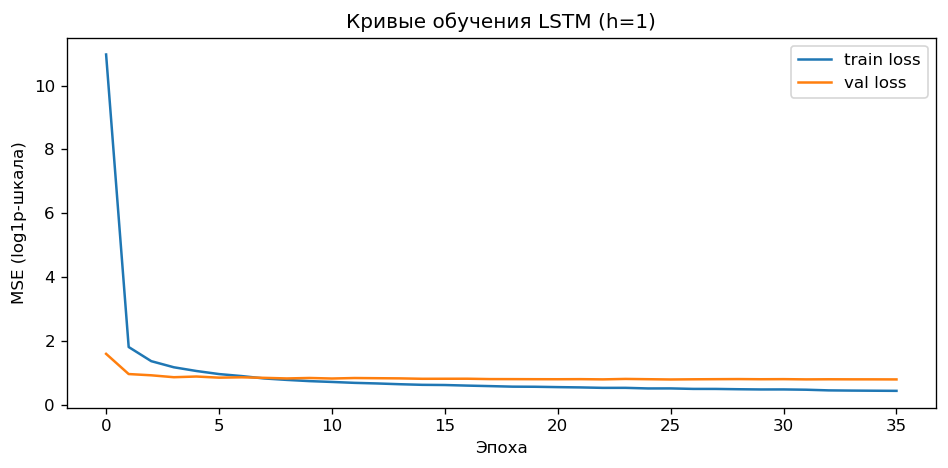

[OK] График сохранён: fig_3_lstm_training_curve.png


In [17]:
h_plot = 1
if h_plot in histories_lstm:
    hist = histories_lstm[h_plot]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(hist["loss"],     label="train loss")
    ax.plot(hist["val_loss"], label="val loss")
    ax.set_xlabel("Эпоха")
    ax.set_ylabel("MSE (log1p-шкала)")
    ax.set_title(f"Кривые обучения LSTM (h={h_plot})")
    ax.legend()
    fig.tight_layout()
    FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES / "fig_3_lstm_training_curve.png")
    plt.show()
    print("[OK] График сохранён: fig_3_lstm_training_curve.png")
else:
    print(f"[SKIP] h={h_plot} не был обучен.")

## Ячейка 5 — График прогноз vs факт (h=1)

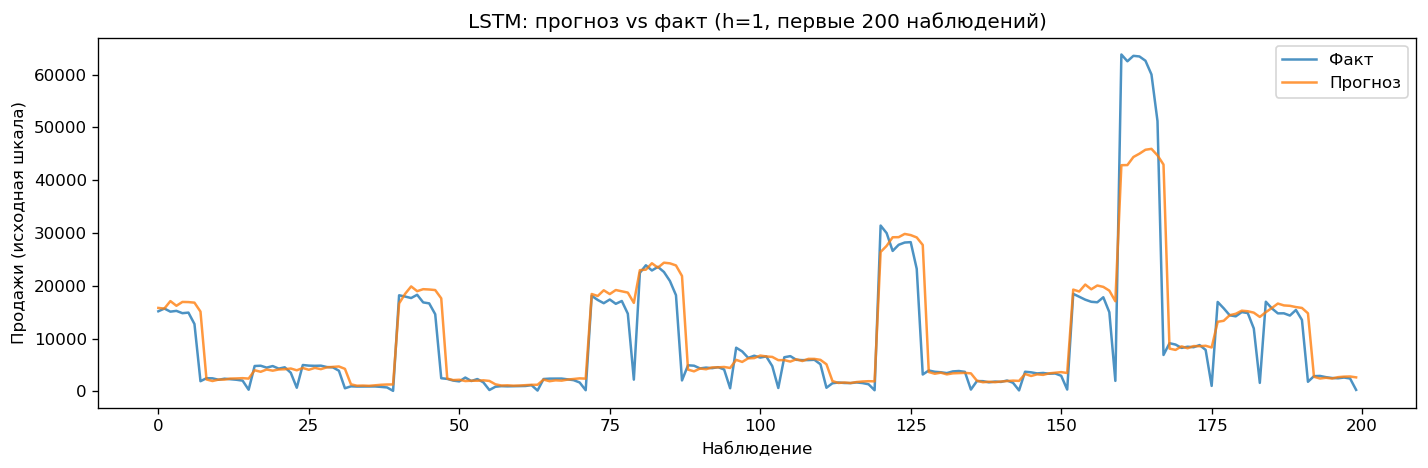

[OK] График сохранён: fig_3_forecast_lstm_h1.png


In [18]:
h_plot = 1
if h_plot in models_lstm:
    target_col = f"target_h{h_plot}"
    df_h_s_plot = make_horizon_target(df_all_s, horizon=h_plot)
    df_h_s_plot = df_h_s_plot[df_h_s_plot[FAMILY_COL].isin(TOP_FAMILIES)]
    test_h_plot = df_h_s_plot[df_h_s_plot[DATE_COL] >= cutoff].dropna(subset=[target_col])

    X_te_plot, y_te_plot = build_sequences(test_h_plot, FEATURE_COLS, target_col, SEQ_LEN)

    model_l = models_lstm[h_plot]
    model_l.eval()
    with torch.no_grad():
        pred_log_plot = model_l(
            torch.tensor(X_te_plot, dtype=torch.float32).to(DEVICE)
        ).cpu().numpy()

    n_show = min(200, len(y_te_plot))
    y_true_orig = np.expm1(y_te_plot[:n_show])
    y_pred_orig = np.expm1(pred_log_plot[:n_show])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y_true_orig, label="Факт",    alpha=0.8)
    ax.plot(y_pred_orig, label="Прогноз", alpha=0.8)
    ax.set_xlabel("Наблюдение")
    ax.set_ylabel("Продажи (исходная шкала)")
    ax.set_title(f"LSTM: прогноз vs факт (h={h_plot}, первые {n_show} наблюдений)")
    ax.legend()
    fig.tight_layout()
    FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES / "fig_3_forecast_lstm_h1.png")
    plt.show()
    print("[OK] График сохранён: fig_3_forecast_lstm_h1.png")
else:
    print(f"[SKIP] h={h_plot} не был обучен.")

## Ячейка 6 — Таблица метрик LSTM

In [19]:
rows = []
for h in FORECAST_HORIZONS:
    m = results_lstm.get(h, {"RMSE": float("nan"), "MAE": float("nan"), "MAPE": float("nan")})
    rows.append({"Горизонт (нед.)": h, "RMSE": m["RMSE"], "MAE": m["MAE"], "MAPE (%)": m["MAPE"]})

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))

TABLES.mkdir(parents=True, exist_ok=True)
df_metrics.to_csv(TABLES / "table_3_metrics_lstm.csv", index=False)
print("\n[OK] Таблица метрик сохранена: table_3_metrics_lstm.csv")

 Горизонт (нед.)        RMSE         MAE   MAPE (%)
               1 5823.018386 2366.576185  87.859669
               3 6189.031791 2749.825591 115.375777
               6 7214.553434 3625.490318 207.342739
              12         NaN         NaN        NaN

[OK] Таблица метрик сохранена: table_3_metrics_lstm.csv


## Ячейка 7 — Сохранение моделей

In [20]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
for h, model in models_lstm.items():
    path = MODELS_DIR / f"lstm_h{h}.pt"
    torch.save(model.state_dict(), path)
    print(f"[OK] Модель h={h} сохранена: {path.name}")

[OK] Модель h=1 сохранена: lstm_h1.pt
[OK] Модель h=3 сохранена: lstm_h3.pt
[OK] Модель h=6 сохранена: lstm_h6.pt
